In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

/home/user/.local/lib/python3/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('ai_student_impact_dataset.csv', sep=',')

#EDA

In [3]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

Проверим, ести ли пропуски в данных

In [5]:
df.isna().any()

Student_ID                    False
Major_Category                False
Year_of_Study                 False
Pre_Semester_GPA              False
Weekly_GenAI_Hours            False
Primary_Use_Case              False
Prompt_Engineering_Skill      False
Tool_Diversity                False
Paid_Subscription             False
Traditional_Study_Hours       False
Perceived_AI_Dependency       False
Institutional_Policy          False
Anxiety_Level_During_Exams    False
Post_Semester_GPA             False
Skill_Retention_Score         False
Burnout_Risk_Level            False
dtype: bool

Пропусков нет.

##Рассмотрим основные распределения:

###1. Область обучения студента

In [6]:
df.Major_Category.unique()

array(['Humanities', 'Medical', 'Business', 'STEM', 'Arts'], dtype=object)

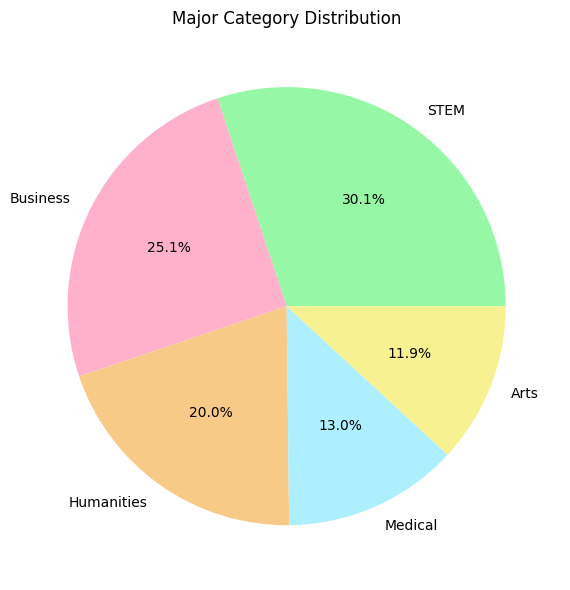

In [7]:
major_counts = df.Major_Category.value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    major_counts,
    labels=major_counts.index,
    autopct='%1.1f%%',
    colors=["#96F8A6", "#FFB0CB", "#F7CA88", "#ADEFFF", "#F8F191"]
)

plt.title('Major Category Distribution')
plt.tight_layout()

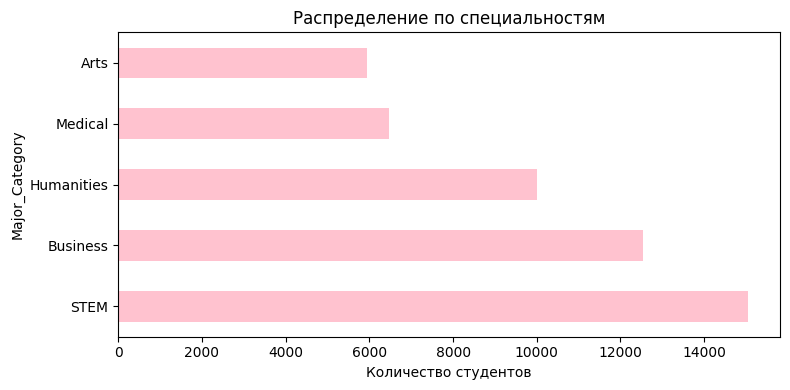

In [8]:
plt.figure(figsize=(8, 4))
major_counts.plot(kind='barh', color="#FFC2CF")
plt.xlabel('Количество студентов')
plt.title('Распределение по специальностям')
plt.tight_layout()
plt.show()

Большинство студентов обучаются по специальностям в области STEM (наука, технология, инженерия и математика) и бизнеса.

###2. Год обучения

In [9]:
df.Year_of_Study.unique()

array(['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate'],
      dtype=object)

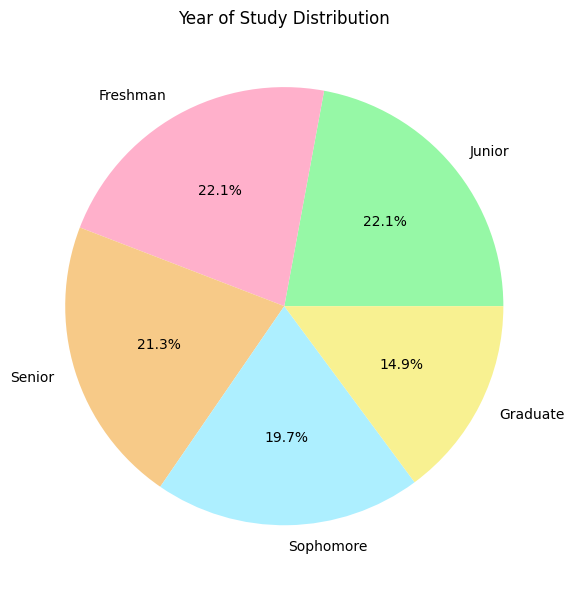

In [10]:
year_counts = df.Year_of_Study.value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    year_counts,
    labels=year_counts.index,
    autopct='%1.1f%%',
    colors=["#96F8A6", "#FFB0CB", "#F7CA88", "#ADEFFF", "#F8F191"]
)

plt.title('Year of Study Distribution')
plt.tight_layout()

Годы обучения сбалансированы, что позволяет корректно сравнивать GPA, использование ИИ и уровень выгорания между первокурсниками и старшекурсниками без поправки на размер группы.

###3. Среднее количество часов в неделю, затраченных на использование инструментов генеративного искусственного интеллекта

In [11]:
df.Weekly_GenAI_Hours.describe()

count    50000.000000
mean         8.427752
std          8.269490
min          0.000000
25%          2.390000
50%          5.800000
75%         11.720000
max         40.000000
Name: Weekly_GenAI_Hours, dtype: float64

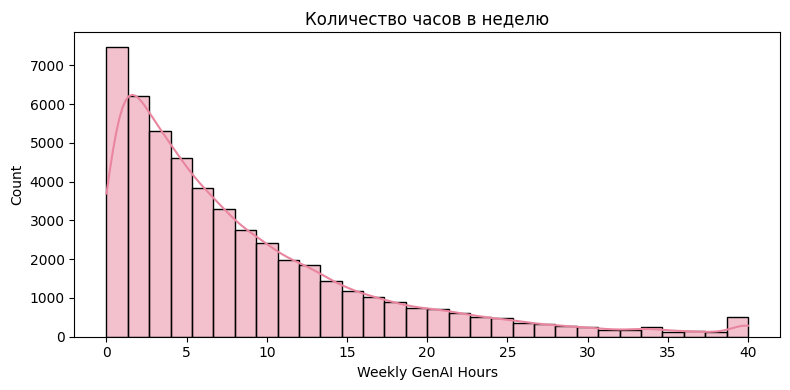

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df.Weekly_GenAI_Hours, bins=30, kde=True, color="#E9859E")
plt.xlabel('Weekly GenAI Hours')
plt.title('Количество часов в неделю')
plt.tight_layout()
plt.show()

В среднем студенты используют GenAI 8.4 часа в неделю, т.е. чуть больше 1 часа в день.
Распределение Weekly_GenAI_Hours имеет асимметрию: большинство студентов тратят ≤5 часов в неделю, тогда как экстремально высокое использование (>20 часов) встречается редко.

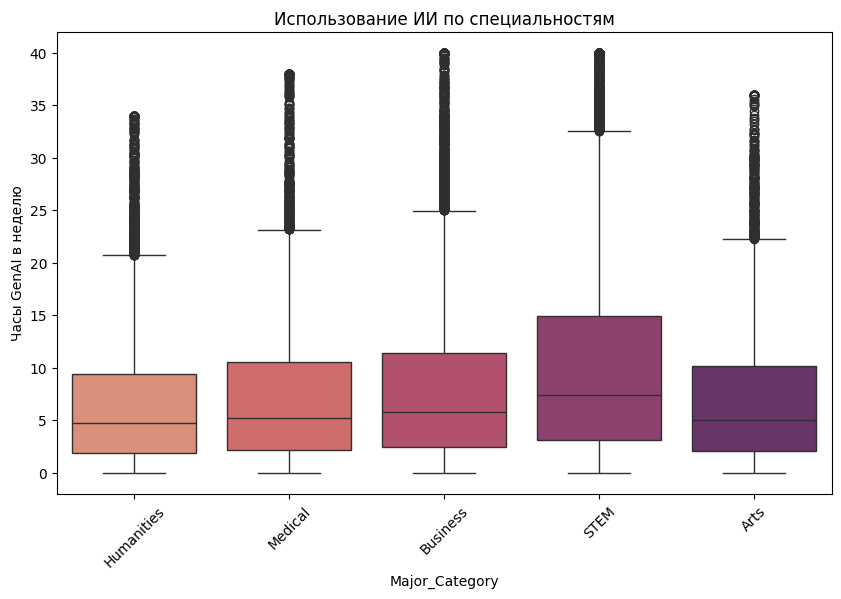

Major_Category
STEM          10.488609
Business       8.275898
Medical        7.546728
Arts           7.271702
Humanities     6.770144
Name: Weekly_GenAI_Hours, dtype: float64

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Major_Category', y='Weekly_GenAI_Hours', hue='Major_Category', palette='flare')
plt.xticks(rotation=45)
plt.title('Использование ИИ по специальностям')
plt.ylabel('Часы GenAI в неделю')
plt.show()

df.groupby('Major_Category')['Weekly_GenAI_Hours'].mean().sort_values(ascending=False)

В STEM специальностях использование ИИ варьируется сильнее, чем в других областях - возможно, потому что одни студенты активно интегрируют ИИ в технические задачи, а другие предпочитают традиционные методы

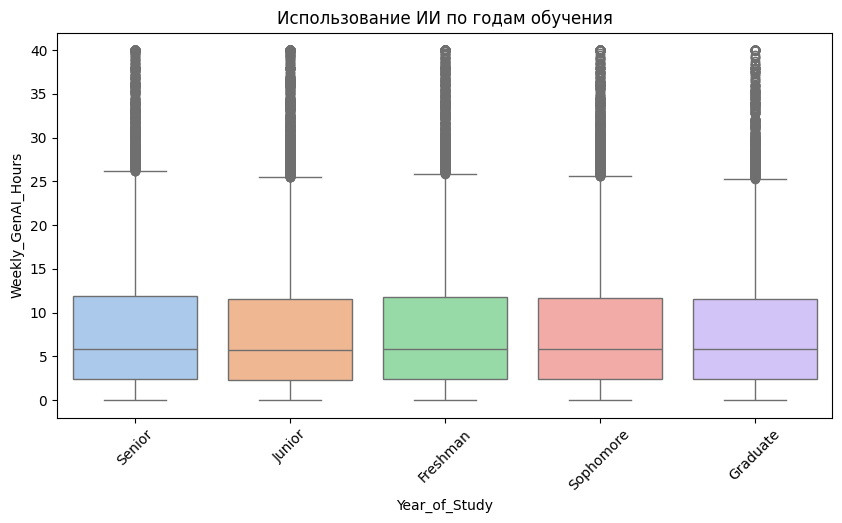

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Year_of_Study', y='Weekly_GenAI_Hours', hue='Year_of_Study', palette='pastel')
plt.title('Использование ИИ по годам обучения')
plt.xticks(rotation=45)
plt.show()

Использование ИИ не зависит от года обучения: все курсы демонстрируют схожий уровень применения GenAI. Это может указывать на то, что ИИ воспринимается как универсальный инструмент, а не как технология, осваиваемая постепенно

###4. Средний балл успеваемости на начало семестра 

Разброс среднего балла по всем студентам:

In [15]:
df.Pre_Semester_GPA.describe()

count    50000.000000
mean         3.146102
std          0.478854
min          1.183000
25%          2.834000
50%          3.210000
75%          3.521000
max          3.998000
Name: Pre_Semester_GPA, dtype: float64

In [16]:
print(f"Skewness: {df.Pre_Semester_GPA.skew():.2f}") 
print(f"Kurtosis: {df.Pre_Semester_GPA.kurtosis():.2f}") 

Skewness: -0.60
Kurtosis: -0.10


GPA имеет умеренное левостороннее смещение (skew = -0.60), что указывает на небольшое количество студентов с аномально низкой успеваемостью. Эксцесс близок к нулю (kurtosis = -0.10), распределение практически нормальное.

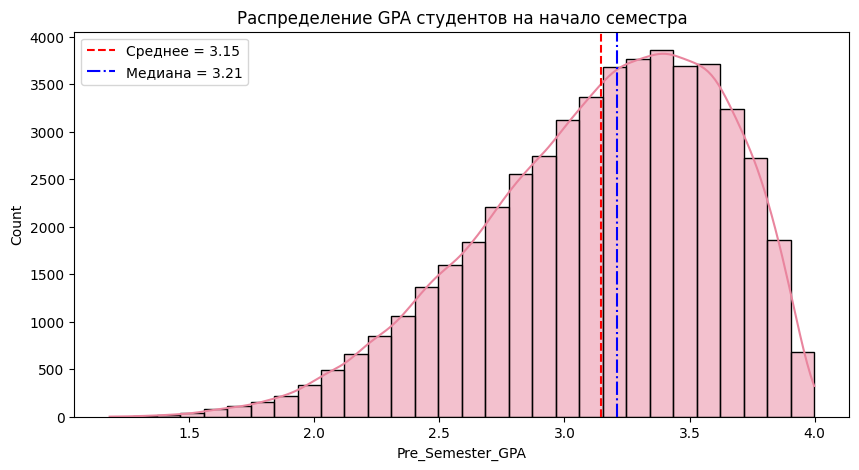

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df.Pre_Semester_GPA, bins=30, kde=True, color="#E9859E")
plt.axvline(df.Pre_Semester_GPA.mean(), color='red', linestyle='--', label=f'Среднее = {df.Pre_Semester_GPA.mean():.2f}')
plt.axvline(df.Pre_Semester_GPA.median(), color='blue', linestyle='-.', label=f'Медиана = {df.Pre_Semester_GPA.median():.2f}')
plt.legend()
plt.title('Распределение GPA студентов на начало семестра', fontsize=12)
plt.show()

Полученная гистограмма подтверджает выводы, сделанные ранее

###5. Средний балл успеваемости в конце семестра 

In [18]:
df.Post_Semester_GPA.describe()

count    50000.000000
mean         3.349299
std          0.495673
min          1.000000
25%          3.023750
50%          3.421000
75%          3.749000
max          4.000000
Name: Post_Semester_GPA, dtype: float64

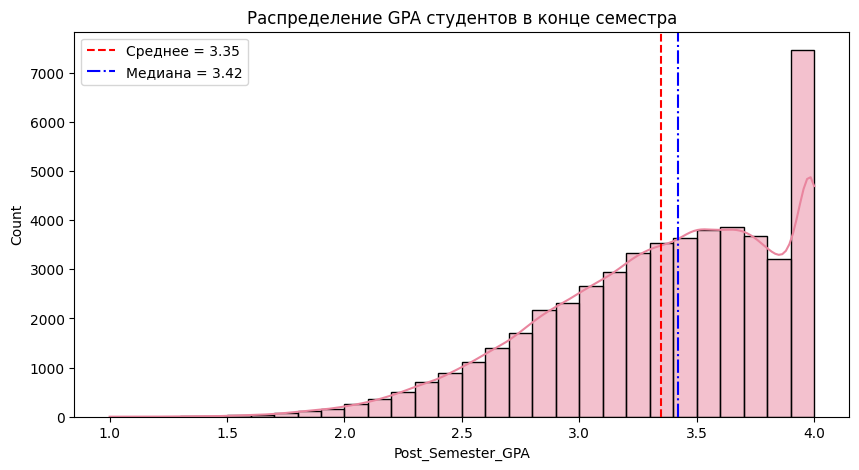

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df.Post_Semester_GPA, bins=30, kde=True, color="#E9859E")
plt.axvline(df.Post_Semester_GPA.mean(), color='red', linestyle='--', label=f'Среднее = {df.Post_Semester_GPA.mean():.2f}')
plt.axvline(df.Post_Semester_GPA.median(), color='blue', linestyle='-.', label=f'Медиана = {df.Post_Semester_GPA.median():.2f}')
plt.legend()
plt.title('Распределение GPA студентов в конце семестра', fontsize=12)
plt.show()

Совмещенная гистограмма распределения успеваемости студентов на начало и конец семестра

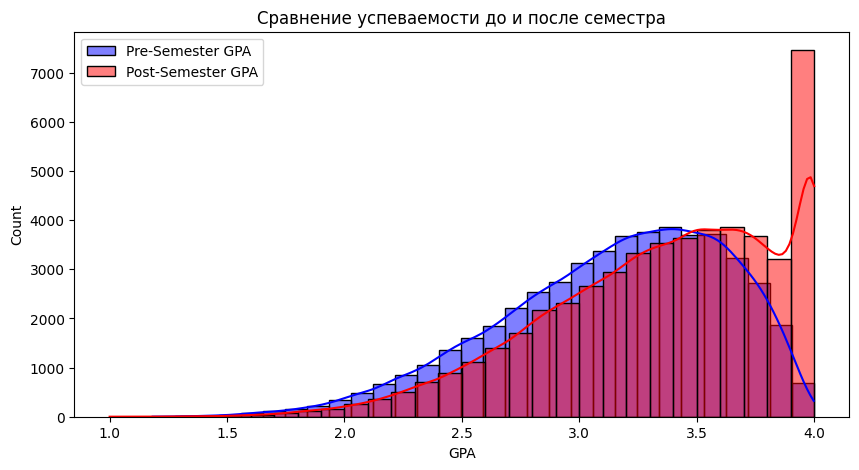

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['Pre_Semester_GPA'], bins=30, kde=True, 
             color='blue', alpha=0.5, label='Pre-Semester GPA')
sns.histplot(df['Post_Semester_GPA'], bins=30, kde=True, 
             color='red', alpha=0.5, label='Post-Semester GPA')

plt.xlabel('GPA')
plt.ylabel('Count')
plt.title('Сравнение успеваемости до и после семестра')
plt.legend()
plt.show()

Красный график (Post) сдвинут вправо → успеваемость выросла

Посчитаем изменение GPA:

In [4]:
df['GPA_Change'] = df.Post_Semester_GPA - df.Pre_Semester_GPA
df.GPA_Change.describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Change, dtype: float64

In [22]:
improved = (df.GPA_Change > 0).sum()
pct_improved = improved / len(df) * 100
print(f"Улучшили GPA: {pct_improved:.1f}%")

declined = (df.GPA_Change < 0).sum()
pct_declined = declined / len(df) * 100
print(f"Ухудшили GPA: {pct_declined:.1f}%")

same = (df.GPA_Change == 0).sum()
pct_same = same / len(df) * 100
print(f"Не изменили: {pct_same:.1f}%")

Улучшили GPA: 87.5%
Ухудшили GPA: 12.4%
Не изменили: 0.1%


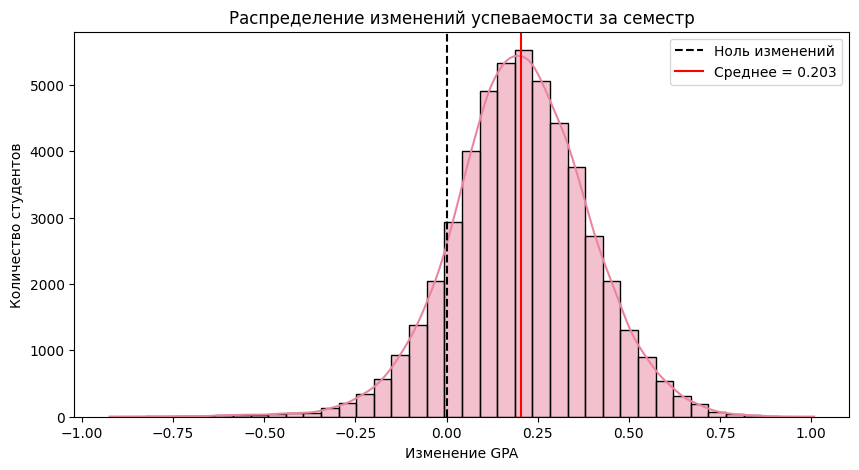

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(df.GPA_Change, bins=40, kde=True, color="#E9859E")
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Ноль изменений')
plt.axvline(df.GPA_Change.mean(), color='red', linestyle='-', 
            label=f"Среднее = {df.GPA_Change.mean():.3f}")
plt.xlabel('Изменение GPA')
plt.ylabel('Количество студентов')
plt.title('Распределение изменений успеваемости за семестр')
plt.legend()
plt.show()

Проверим статистическую значимость:

In [24]:
t_stat, p_value = ttest_rel(df.Pre_Semester_GPA, df.Post_Semester_GPA)
print(f"p-value: {p_value:.10f}")
print('Разница статистически значима (p < 0.05)' if p_value < 0.05 else 'Разница не значима')

p-value: 0.0000000000
Разница статистически значима (p < 0.05)


In [25]:
big_improvers = df[df['GPA_Change'] > 0.5]
print(f"Сильно улучшили GPA (>+0.5): {len(big_improvers)} студентов")

big_decliners = df[df['GPA_Change'] < -0.5]
print(f"Сильно ухудшили GPA (<-0.5): {len(big_decliners)} студентов")

big_improvers[['Major_Category', 'Year_of_Study', 'Weekly_GenAI_Hours', 'GPA_Change']].head()

Сильно улучшили GPA (>+0.5): 2649 студентов
Сильно ухудшили GPA (<-0.5): 106 студентов


,Major_Category,Year_of_Study,Weekly_GenAI_Hours,GPA_Change
13,STEM,Junior,8.95,0.710
25,Arts,Senior,2.38,0.692
49,STEM,Senior,13.39,0.529
78,Humanities,Graduate,8.84,0.551
91,Business,Junior,5.87,0.547


Группа экстремального роста в 25 раз больше группы экстремального падения.

Сравним изменение GPA по различным категориям

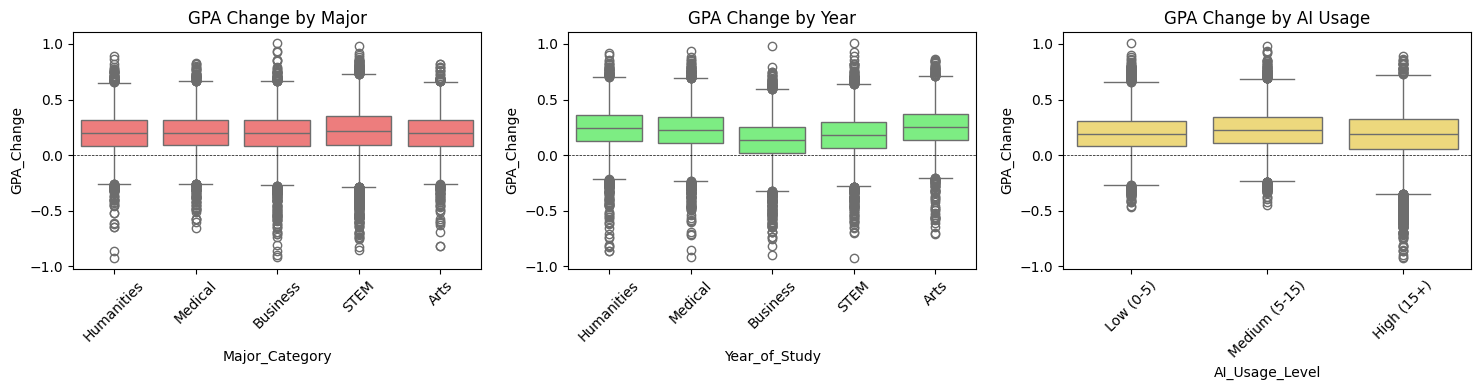

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='Major_Category', y='GPA_Change', ax=axes[0], color='#FF6B6B')
tick_locations = axes[0].get_xticks()
axes[0].set_xticks(tick_locations)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title('GPA Change by Major')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)

sns.boxplot(data=df, x='Year_of_Study', y='GPA_Change', ax=axes[1], color="#6BFF72")
tick_locations = axes[1].get_xticks()
axes[1].set_xticks(tick_locations)
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_title('GPA Change by Year')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)

df['AI_Usage_Level'] = pd.cut(df['Weekly_GenAI_Hours'], 
                               bins=[0, 5, 15, 41], 
                               labels=['Low (0-5)', 'Medium (5-15)', 'High (15+)'])
sns.boxplot(data=df, x='AI_Usage_Level', y='GPA_Change', ax=axes[2], color="#FFE46B")
tick_locations = axes[2].get_xticks()
axes[2].set_xticks(tick_locations)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
axes[2].set_title('GPA Change by AI Usage')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Во всех группах медианное изменение GPA положительно.
Различия между направлениями подготовки невелики, хотя студенты STEM демонстрируют немного больший прирост GPA.
Первокурсники имеют самый низкий прирост GPA, тогда как студенты старших курсов показывают более высокие значения.
Высокая интенсивность использования GenAI не связана с заметным изменением среднего прироста GPA.

###6. Основная цель использования ИИ

In [29]:
use_case_dist = df['Primary_Use_Case'].value_counts()
use_case_pct = df['Primary_Use_Case'].value_counts(normalize=True) * 100

use_case_summary = pd.DataFrame({
    'Количество': use_case_dist,
    'Процент': use_case_pct.round(1)
})
use_case_summary

,Количество,Процент
Primary_Use_Case,,
Debugging/Troubleshooting,12295,24.6
Copywriting/Drafting,12011,24.0
Ideation,10721,21.4
Summarizing_Reading,8633,17.3
Direct_Answer_Generation,6340,12.7


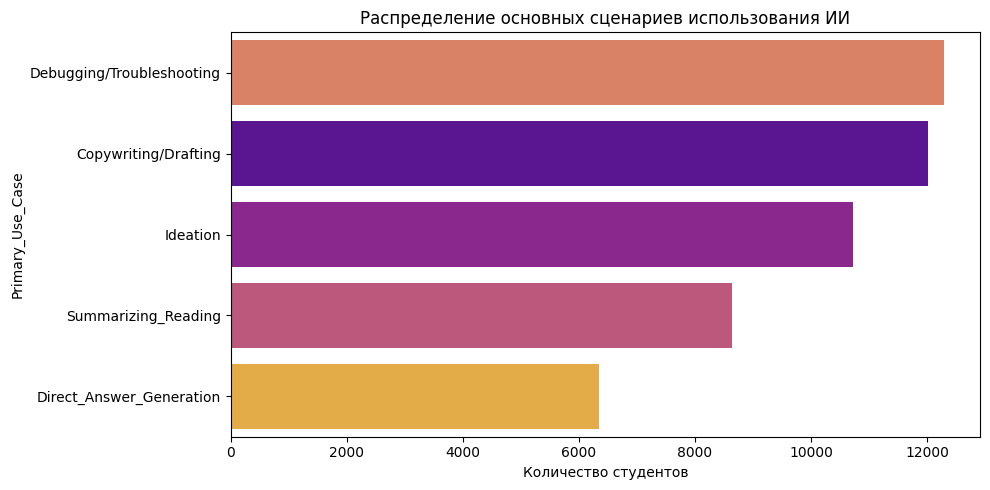

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Primary_Use_Case', hue='Primary_Use_Case', legend=False, order=use_case_dist.index, 
              palette='plasma')
plt.xlabel('Количество студентов')
plt.title('Распределение основных сценариев использования ИИ')
plt.tight_layout()
plt.show()

Большинство студентов используют ИИ для дебага

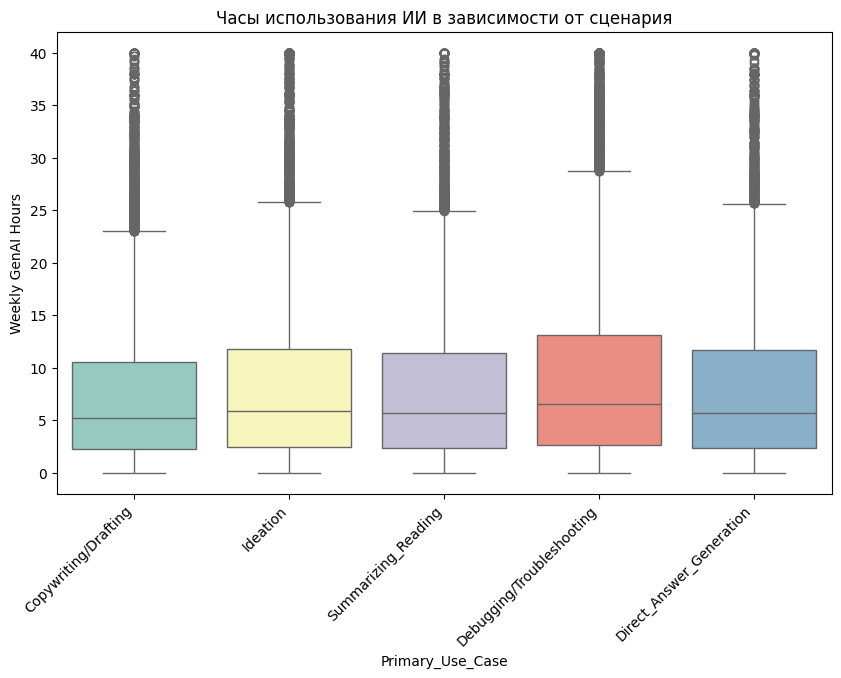

Primary_Use_Case
Debugging/Troubleshooting    9.40
Direct_Answer_Generation     8.46
Ideation                     8.40
Summarizing_Reading          8.17
Copywriting/Drafting         7.63
Name: Weekly_GenAI_Hours, dtype: float64

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Primary_Use_Case', y='Weekly_GenAI_Hours', hue='Primary_Use_Case', legend=False, palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Часы использования ИИ в зависимости от сценария')
plt.ylabel('Weekly GenAI Hours')
plt.show()

df.groupby('Primary_Use_Case')['Weekly_GenAI_Hours'].mean().sort_values(ascending=False).round(2)

Debugging/Troubleshooting ожидаемо лидирует по средним часам использования и вариативности. Это объясняется природой задач: написание и отладка кода — итеративный процесс, требующий множества циклов "запрос → проверка → уточнение", что естественным образом увеличивает время взаимодействия с ИИ. Кроме того, сложность задач варьируется от простых фиксов до глубокой отладки сложных систем, что даёт высокий разброс.

На противоположном полюсе — Copywriting/Drafting. Работа с текстом (генерация черновиков, переформулирование) обычно требует одного-двух запросов и минимальной доработки, что объясняет низкое среднее и малый разброс. Это более "линейный" сценарий использования, где ИИ выступает быстрым генератором, а не интерактивным помощником.

###7. Самооценка уровня владения навыками составления эффективных промптов

In [5]:
df.Prompt_Engineering_Skill.value_counts().sort_index()

Prompt_Engineering_Skill
Advanced        13809
Beginner        18495
Intermediate    17696
Name: count, dtype: int64

Большинство студентов оценивают свои навыки промпт-инжиниринга как начальные или средние.

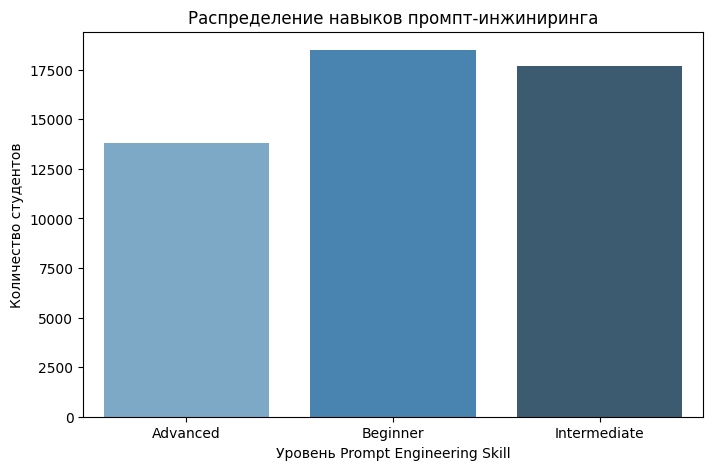

Prompt_Engineering_Skill
Advanced        27.6
Beginner        37.0
Intermediate    35.4
Name: count, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
skill_dist = df['Prompt_Engineering_Skill'].value_counts().sort_index()
sns.barplot(x=skill_dist.index, y=skill_dist.values, hue=skill_dist.index, palette='Blues_d')
plt.xlabel('Уровень Prompt Engineering Skill')
plt.ylabel('Количество студентов')
plt.title('Распределение навыков промпт-инжиниринга')
plt.show()

print((skill_dist / len(df) * 100).round(1))

Prompt Skill vs GPA_Change

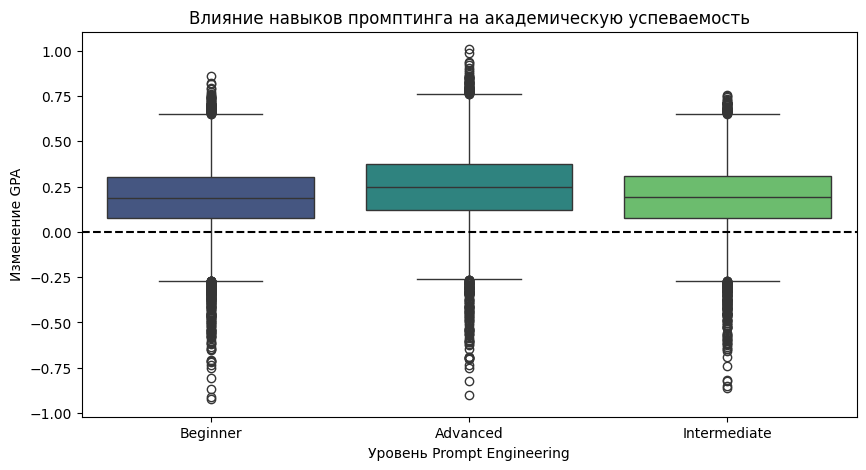

Prompt_Engineering_Skill
Advanced        0.2481
Beginner        0.1852
Intermediate    0.1869
Name: GPA_Change, dtype: float64

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='GPA_Change', hue='Prompt_Engineering_Skill', palette='viridis')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Уровень Prompt Engineering')
plt.ylabel('Изменение GPA')
plt.title('Влияние навыков промптинга на академическую успеваемость')
plt.show()

df.groupby('Prompt_Engineering_Skill')['GPA_Change'].mean().round(4)

Максимальное улучшение среднего балла наблюдается у тех студентов, которые высоко оценивают свои навыки использования генеративного ИИ.

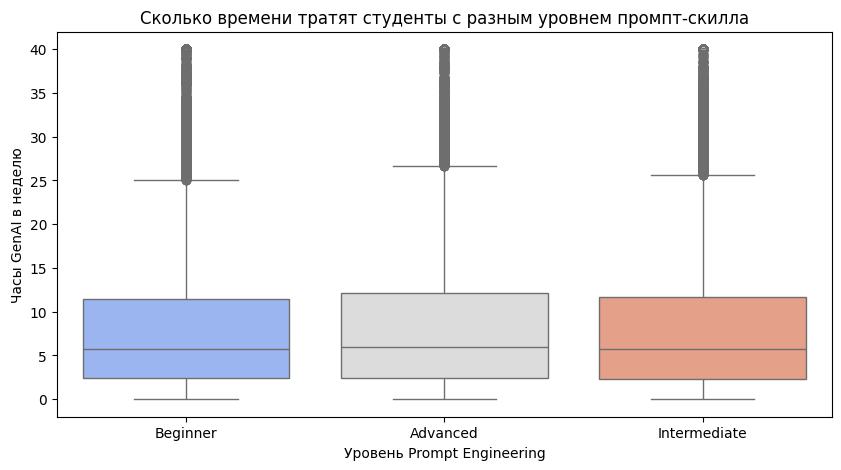

Prompt_Engineering_Skill
Advanced        8.69
Beginner        8.29
Intermediate    8.37
Name: Weekly_GenAI_Hours, dtype: float64

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='Weekly_GenAI_Hours', hue='Prompt_Engineering_Skill', palette='coolwarm')
plt.xlabel('Уровень Prompt Engineering')
plt.ylabel('Часы GenAI в неделю')
plt.title('Сколько времени тратят студенты с разным уровнем промпт-скилла')
plt.show()

df.groupby('Prompt_Engineering_Skill')['Weekly_GenAI_Hours'].mean().round(2)

Интересно, что умелые пользователи тратят немного больше часов на использование ИИ, что может говорить об их сильной вовлеченности. 

Сравним средний скилл у сиудентов STEM и не STEM специальностей

In [16]:
df['Is_STEM'] = df['Major_Category'] == 'STEM'

In [18]:
pd.crosstab(df['Prompt_Engineering_Skill'], df['Is_STEM'])

Is_STEM,False,True
Prompt_Engineering_Skill,,
Advanced,8736,5073
Beginner,13932,4563
Intermediate,12273,5423


STEM-студенты имеют более высокий уровень владения промптами. В то же время Beginner-уровень преобладает среди Non-STEM

###Количество используемых различных инструментов ИИ

In [7]:
df.Tool_Diversity.describe()

count    50000.00000
mean         2.80026
std          1.18802
min          1.00000
25%          2.00000
50%          3.00000
75%          4.00000
max          5.00000
Name: Tool_Diversity, dtype: float64

In [5]:
df.Tool_Diversity.value_counts().sort_index()

Tool_Diversity
1     8141
2    11830
3    16926
4     8081
5     5022
Name: count, dtype: int64

В среднем, студенты пользуются 2-3 инструментами

Tool Diversity vs Prompt_Engineering_Skill

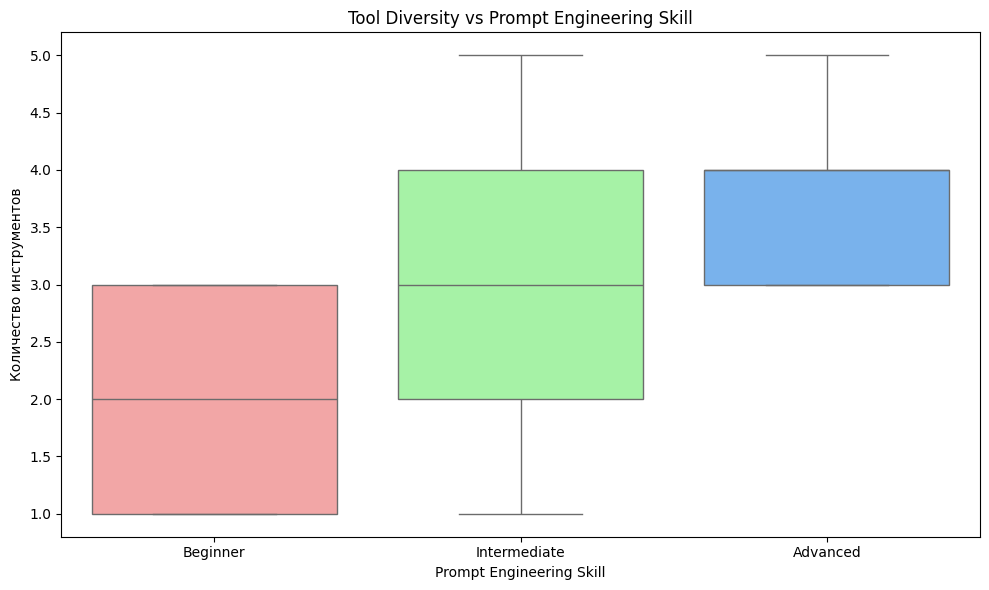

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='Tool_Diversity', hue='Prompt_Engineering_Skill',
            order=['Beginner', 'Intermediate', 'Advanced'], 
            palette=['#FF9999', '#66B2FF', '#99FF99'])

plt.title('Tool Diversity vs Prompt Engineering Skill', 
          fontsize=12)
plt.ylabel('Количество инструментов')
plt.xlabel('Prompt Engineering Skill')
plt.tight_layout()
plt.show()

In [11]:
df.groupby('Prompt_Engineering_Skill')['Tool_Diversity'].describe()

,count,mean,std,min,25%,50%,75%,max
Prompt_Engineering_Skill,,,,,,,,
Advanced,13809.0,3.805996,0.796468,3.0,3.0,4.0,4.0,5.0
Beginner,18495.0,2.007245,0.776988,1.0,1.0,2.0,3.0,3.0
Intermediate,17696.0,2.844259,1.188881,1.0,2.0,3.0,4.0,5.0


In [12]:
df.groupby('Prompt_Engineering_Skill')['Tool_Diversity'].median()

Prompt_Engineering_Skill
Advanced        4.0
Beginner        2.0
Intermediate    3.0
Name: Tool_Diversity, dtype: float64

Beginner используют только 1-3 инструмента, Intermediate в основном пользуются 2-4, Advanced - от 3 инструментов.

Получается, студенты, считающие себя продвинутыми пользователями, пользуются большим числом ИИ-инструментов

##Корреляция числовых признаков

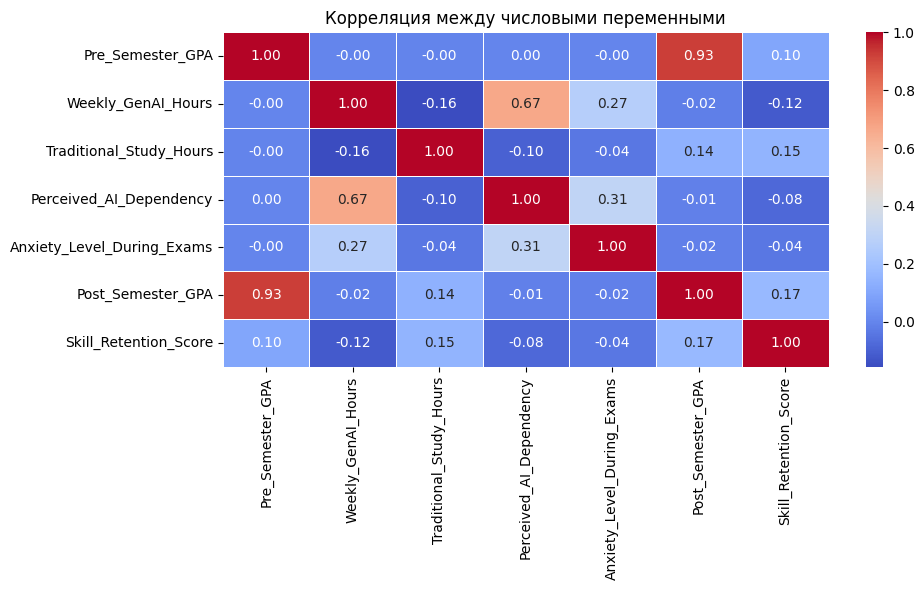

In [27]:
numeric_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
                'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 
                'Post_Semester_GPA', 'Skill_Retention_Score']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5)
plt.title('Корреляция между числовыми переменными')
plt.tight_layout()
plt.show()

Наиболее сильная связь наблюдается между `Pre_Semester_GPA` и `Post_Semester_GPA` (r = 0.93), что говорит о высокой стабильности академической успеваемости студентов.
Часы использования GenAI умеренно коррелируют с субъективной зависимостью от ИИ (`Perceived_AI_Dependency`, r = 0.67).
Связь между использованием GenAI и уровнем тревожности во время экзаменов слабая (r = 0.27).
Корреляция между использованием GenAI и сохранением знаний (`Skill_Retention_Score`) практически отсутствует (r = -0.12).
Традиционные часы обучения слабо связаны с итоговым GPA (r = 0.14) и уровнем сохранения знаний (r = 0.15).
Большинство остальных коэффициентов близки к нулю, что указывает на отсутствие выраженных линейных зависимостей.

In [28]:
for major in df['Major_Category'].unique():
    subset = df[df['Major_Category'] == major]
    corr = subset['Weekly_GenAI_Hours'].corr(subset['Anxiety_Level_During_Exams'])
    print(f"{major}: {corr:.2f}")

Humanities: 0.23
Medical: 0.25
Business: 0.25
STEM: 0.31
Arts: 0.24


STEM-студенты демонстрируют более сильную связь между использованием ИИ и экзаменационной тревожностью.